In [40]:
import numpy as np 
import pandas as pd 
import os
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft/LengthOfStay.csv


In [41]:
filename = "/kaggle/input/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft/LengthOfStay.csv"

In [42]:
df = pd.read_csv(filename)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [44]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [45]:
df.columns

Index(['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma',
       'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor',
       'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
       'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
       'creatinine', 'bmi', 'pulse', 'respiration',
       'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay'],
      dtype='object')

In [46]:
df['rcount'].unique()

array(['0', '5+', '1', '3', '4', '2'], dtype=object)

In [47]:
df['vdate'] = pd.to_datetime(df['vdate'])
df['discharged'] = pd.to_datetime(df['discharged'])

In [48]:
((df['discharged'] - df['vdate']).dt.days == df['lengthofstay']).mean()

np.float64(1.0)

In [49]:
df['admission_month'] = df['vdate'].dt.month
df['admission_day'] = df['vdate'].dt.dayofweek

In [50]:
# Check for data consistency
mismatch = df[df['lengthofstay'] != (df['discharged'] - df['vdate']).dt.days]
print(f"Number of rows where LOS doesn't match dates: {len(mismatch)}")

Number of rows where LOS doesn't match dates: 0


In [51]:
df['gender'] = df['gender'].astype('category')
df['facid'] = df['facid'].astype('category')

In [52]:
df['rcount'] = df['rcount'].astype('category')
df['rcount_5plus'] = (df['rcount'] == '5+').astype(int)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   eid                         100000 non-null  int64         
 1   vdate                       100000 non-null  datetime64[ns]
 2   rcount                      100000 non-null  category      
 3   gender                      100000 non-null  category      
 4   dialysisrenalendstage       100000 non-null  int64         
 5   asthma                      100000 non-null  int64         
 6   irondef                     100000 non-null  int64         
 7   pneum                       100000 non-null  int64         
 8   substancedependence         100000 non-null  int64         
 9   psychologicaldisordermajor  100000 non-null  int64         
 10  depress                     100000 non-null  int64         
 11  psychother                  100000 non-n

In [54]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay,admission_month,admission_day,rcount_5plus
0,1,2012-08-29,0,F,0,0,0,0,0,0,...,30.432418,96,6.5,4,2012-09-01,B,3,8,2,0
1,2,2012-05-26,5+,F,0,0,0,0,0,0,...,28.460516,61,6.5,1,2012-06-02,A,7,5,5,1
2,3,2012-09-22,1,F,0,0,0,0,0,0,...,28.843812,64,6.5,2,2012-09-25,B,3,9,5,0
3,4,2012-08-09,0,F,0,0,0,0,0,0,...,27.959007,76,6.5,1,2012-08-10,A,1,8,3,0
4,5,2012-12-20,0,F,0,0,0,1,0,1,...,30.258927,67,5.6,2,2012-12-24,E,4,12,3,0


In [55]:
df_c = df.drop(columns=['eid','facid'])
df_c.select_dtypes(include=['number']).corr()

,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,...,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,admission_month,admission_day,rcount_5plus
dialysisrenalendstage,1.000000,-0.005340,0.157381,0.120472,0.049925,0.085162,0.013229,0.311179,0.018211,0.209172,...,0.272239,-0.000372,0.003331,0.003802,-0.043435,0.003251,0.169695,0.001880,0.000423,0.003034
asthma,-0.005340,1.000000,0.020001,0.058444,-0.005668,0.026300,0.026402,-0.008556,0.015787,0.008620,...,-0.005675,-0.001479,-0.000597,0.006473,0.001910,-0.001108,0.082005,0.004810,-0.000889,-0.000222
irondef,0.157381,0.020001,1.000000,0.151320,0.082848,0.127544,0.019041,0.176662,0.021999,0.300174,...,0.149846,-0.010980,-0.005841,0.002803,-0.047849,0.006194,0.193838,-0.002603,0.001070,-0.002267
pneum,0.120472,0.058444,0.151320,1.000000,0.076131,0.089732,0.016293,0.090839,0.025374,0.133551,...,0.064899,-0.001437,0.000650,0.005045,-0.055898,0.000590,0.135461,-0.007143,0.004661,0.000770
substancedependence,0.049925,-0.005668,0.082848,0.076131,1.000000,0.081762,0.004690,0.087252,0.007624,0.048180,...,0.073065,0.002481,-0.001434,0.002433,-0.058826,-0.000814,0.147886,-0.002676,0.002279,-0.000091
psychologicaldisordermajor,0.085162,0.026300,0.127544,0.089732,0.081762,1.000000,0.295137,0.096239,0.015112,0.119817,...,0.073234,-0.000066,-0.000749,0.000377,0.065988,0.005916,0.286724,0.003148,0.005219,-0.000225
depress,0.013229,0.026402,0.019041,0.016293,0.004690,0.295137,1.000000,-0.001908,0.011945,0.019038,...,0.007889,-0.002212,0.001648,0.007289,0.040031,0.001255,0.121408,-0.002916,-0.000938,-0.000130
psychother,0.311179,-0.008556,0.176662,0.090839,0.087252,0.096239,-0.001908,1.000000,0.002234,0.310403,...,0.347354,-0.005638,0.002643,0.001140,-0.028148,0.006368,0.191695,0.000779,0.003239,0.001207
fibrosisandother,0.018211,0.015787,0.021999,0.025374,0.007624,0.015112,0.011945,0.002234,1.000000,0.031589,...,0.021765,-0.002226,-0.004844,-0.000038,-0.038565,0.000843,0.062131,-0.000214,0.002547,-0.001256
malnutrition,0.209172,0.008620,0.300174,0.133551,0.048180,0.119817,0.019038,0.310403,0.031589,1.000000,...,0.267992,-0.004023,-0.002759,0.005217,-0.018937,0.009576,0.174397,0.001984,0.004617,0.002382


In [56]:
df = df.drop(columns=['eid', 'discharged', 'vdate'])

In [57]:
X = df.drop('lengthofstay', axis=1)
y = df['lengthofstay']

In [58]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [59]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42
    }

    model = lgb.LGBMRegressor(**params)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))

    return np.mean(scores)

In [60]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)

[I 2026-05-05 12:38:59,355] A new study created in memory with name: no-name-42bc643b-fad1-4e1d-bbad-7ea2356a117e


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 46666, number of used features: 27
[LightGBM] [Info] Start training from score 4.000129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[I 2026-05-05 12:39:05,154] Trial 0 finished with value: 0.3734264212524217 and parameters: {'n_estimators': 385, 'learning_rate': 0.027649295336309686, 'max_depth': 5, 'num_leaves': 60, 'subsample': 0.742068829208369, 'colsample_bytree': 0.7928699485619204}. Best is trial 0 with value: 0.3734264212524217.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008814 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 46666, number of used features: 27
[LightGBM] [Info] Start training from score 4.000129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1929
[LightGBM] [Info] Number of data points in the train set: 46667, number of used features: 27
[LightGBM] [Info] Start training from score 4.003129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

[I 2026-05-05 12:39:11,936] Trial 1 finished with value: 0.32168862803963727 and parameters: {'n_estimators': 295, 'learning_rate': 0.04855265880367161, 'max_depth': 8, 'num_leaves': 57, 'subsample': 0.9690270193236186, 'colsample_bytree': 0.7482436293649373}. Best is trial 1 with value: 0.32168862803963727.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009823 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 46666, number of used features: 27
[LightGBM] [Info] Start training from score 4.000129
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1929
[LightGBM] [Info] Number of data points in the train set: 46667, number of used features: 27
[LightGBM] [Info] Start training from score 4.003129
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1920
[LightGBM] [Info] Number of data points in the train set: 46667, number of used features: 27
[LightGBM] [Info] Start tra

[I 2026-05-05 12:44:06,116] Trial 28 finished with value: 0.30718168407755203 and parameters: {'n_estimators': 630, 'learning_rate': 0.07749990384396853, 'max_depth': 10, 'num_leaves': 36, 'subsample': 0.8190762347451107, 'colsample_bytree': 0.775585626103835}. Best is trial 21 with value: 0.304344848487066.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1919
[LightGBM] [Info] Number of data points in the train set: 46666, number of used features: 27
[LightGBM] [Info] Start training from score 4.000129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[I 2026-05-05 12:44:18,926] Trial 29 finished with value: 0.3358484032181501 and parameters: {'n_estimators': 671, 'learning_rate': 0.02498971941311771, 'max_depth': 6, 'num_leaves': 53, 'subsample': 0.7561014735226651, 'colsample_bytree': 0.7918119432918929}. Best is trial 21 with value: 0.304344848487066.


Best Parameters: {'n_estimators': 758, 'learning_rate': 0.08017778972971475, 'max_depth': 10, 'num_leaves': 46, 'subsample': 0.7894125870365429, 'colsample_bytree': 0.8649224891402452}


In [61]:
best_params = study.best_params

final_model = lgb.LGBMRegressor(**best_params)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 27
[LightGBM] [Info] Start training from score 4.004629
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[758]	valid_0's l1: 0.292621	valid_0's l2: 0.164589


LGBMRegressor(colsample_bytree=0.8649224891402452,
              learning_rate=0.08017778972971475, max_depth=10, n_estimators=758,
              num_leaves=46, subsample=0.7894125870365429)

In [62]:
preds = final_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("Final MAE:", mae)

Final MAE: 0.2982342855153085


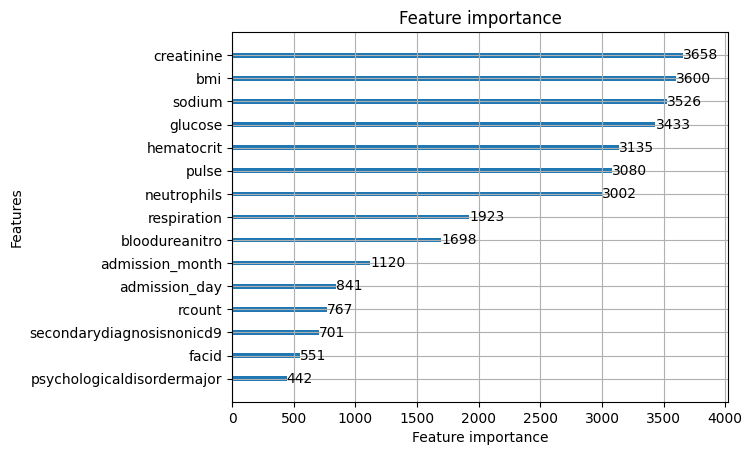

In [63]:
import matplotlib.pyplot as plt

lgb.plot_importance(final_model, max_num_features=15)
plt.show()

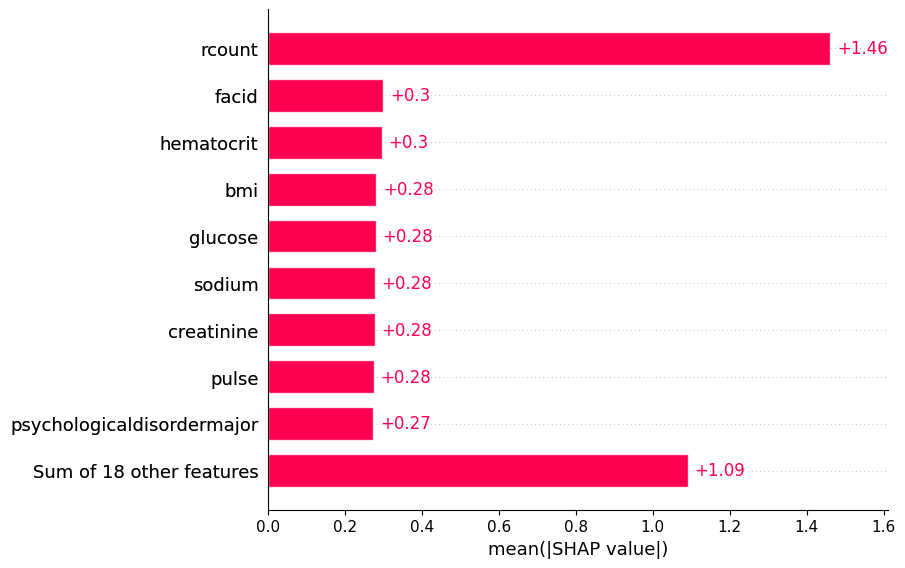

In [64]:
import shap

explainer = shap.Explainer(final_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [65]:
y_shuffled = y.sample(frac=1.0, random_state=42)

model = lgb.LGBMRegressor(**best_params)
model.fit(X_train, y_shuffled.loc[X_train.index])

preds = model.predict(X_test)
print("MAE with shuffled target:", mean_absolute_error(y_test, preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 27
[LightGBM] [Info] Start training from score 4.004629
MAE with shuffled target: 0.2982342855153085


Above code failed upon y_shuffled because of pandas index alignment. y.sample() shuffled the row order, but it kept the original index labels , however , y_shuffled.loc[X_train.index] , selected values by the original index labels, not by shuffled position.

In [76]:
X_train_reset = X_train.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

y_shuffled = np.random.permutation(y_train_reset)

model = lgb.LGBMRegressor(**best_params)
model.fit(X_train_reset, y_shuffled)

preds_shuffle = model.predict(X_test_reset)

from sklearn.metrics import mean_absolute_error
print("MAE with shuffled target:", mean_absolute_error(y_test_reset, preds_shuffle))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1952
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 27
[LightGBM] [Info] Start training from score 4.004629
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

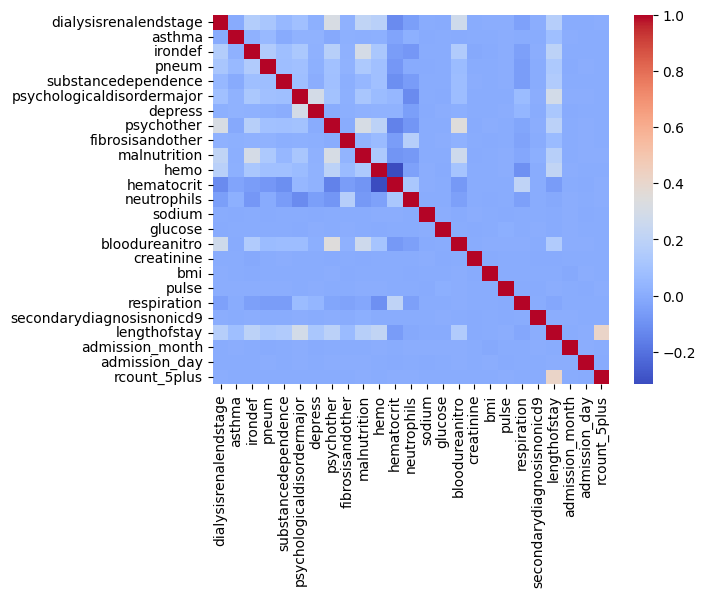

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X.select_dtypes(include=['int64', 'float64'])

vif = pd.DataFrame()
vif["feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]

print(vif.sort_values(by="VIF", ascending=False))

                       feature         VIF
13                      sodium  390.233918
17                         bmi  203.226151
19                 respiration  133.259417
11                  hematocrit   42.660201
18                       pulse   40.137066
16                  creatinine   30.780692
14                     glucose   23.219149
12                 neutrophils    4.985870
15              bloodureanitro    2.650516
20   secondarydiagnosisnonicd9    2.071716
5   psychologicaldisordermajor    1.525624
7                   psychother    1.367694
9                 malnutrition    1.305099
10                        hemo    1.272402
2                      irondef    1.269484
0        dialysisrenalendstage    1.230773
6                      depress    1.159328
4          substancedependence    1.104504
3                        pneum    1.099574
21                rcount_5plus    1.052611
8             fibrosisandother    1.047331
1                       asthma    1.043660


In [68]:
df.duplicated().sum()

np.int64(0)

In [70]:
y.describe()

count    100000.00000
mean          4.00103
std           2.36031
min           1.00000
25%           2.00000
50%           4.00000
75%           6.00000
max          17.00000
Name: lengthofstay, dtype: float64

In [71]:
baseline_pred = np.full_like(y_test, y_train.mean())
print(mean_absolute_error(y_test, baseline_pred))

1.8990666666666667


In [72]:
errors = abs(y_test - preds)
print(errors.describe())

count    15000.000000
mean         0.298234
std          0.285163
min          0.000015
25%          0.082685
50%          0.206042
75%          0.421702
max          2.578841
Name: lengthofstay, dtype: float64


In [73]:
errors = abs(y_test_reset - preds_shuffle)
print(errors.describe())

count    15000.000000
mean         1.942682
std          1.360258
min          0.000015
25%          0.881775
50%          1.839517
75%          2.896163
max         12.955946
Name: lengthofstay, dtype: float64


In [74]:
np.mean(np.abs(y_test - preds) <= 1)

np.float64(0.9742)

In [75]:
np.mean(np.abs(y_test_reset-preds_shuffle)<=1)

np.float64(0.2949333333333333)